## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [3]:
import keras
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

C:\Users\porwaa\AppData\Local\Continuum\anaconda3\lib\site-packages\h5py\__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


### Find no.of samples are there in training and test datasets

In [4]:
# Number of samples in training data
print('Number of samples in train data', x_train.shape[0])

Number of samples in train data 60000


In [5]:
# Number of samples in test data
print('Number of samples in test data', x_test.shape[0])

Number of samples in test data 10000


### Find dimensions of an image in the dataset

In [6]:
print('Dimensions', x_train.shape[1], 'by', x_train.shape[2])


Dimensions 28 by 28


### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [7]:
x_train = x_train/255
x_test = x_test/255

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)



In [8]:
# Reshape the features
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)


### Normalize both the train and test image data from 0-255 to 0-1

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

### Import the necessary layers from keras to build the model

In [9]:
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers
from keras import optimizers


### Build a model 

** with 2 Conv layers having `32 3*3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [10]:
hidden_nodes = 128
output_nodes = 10
       
model1 = Sequential()
model1.add(Dense(hidden_nodes, input_shape=(784,), activation='relu'))
model1.add(Dense(output_nodes, activation='softmax'))
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
#Train the model
model1.fit(x_train, y_train,          
          validation_data=(x_test, y_test),
          epochs=100,
          batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/100
60000/60000 [==============================] - 9s 157us/step - loss: 0.4985 - acc: 0.8237 - val_loss: 0.4309 - val_acc: 0.8445
Epoch 2/100
60000/60000 [==============================] - 9s 142us/step - loss: 0.3797 - acc: 0.8637 - val_loss: 0.4060 - val_acc: 0.8536
Epoch 3/100
60000/60000 [==============================] - 7s 121us/step - loss: 0.3407 - acc: 0.8748 - val_loss: 0.3726 - val_acc: 0.8672
Epoch 4/100
60000/60000 [==============================] - 11s 177us/step - loss: 0.3159 - acc: 0.8837 - val_loss: 0.3500 - val_acc: 0.8750
Epoch 5/100
60000/60000 [==============================] - 8s 137us/step - loss: 0.2961 - acc: 0.8915 - val_loss: 0.3443 - val_acc: 0.8763
Epoch 6/100
60000/60000 [==============================] - 10s 170us/step - loss: 0.2814 - acc: 0.8960 - val_loss: 0.3308 - val_acc: 0.8826
Epoch 7/100
60000/60000 [==============================] - 10s 161us/step - loss: 0.2691 - acc: 0.9006 - val_loss:

60000/60000 [==============================] - 9s 146us/step - loss: 0.0842 - acc: 0.9685 - val_loss: 0.5147 - val_acc: 0.8901
Epoch 60/100
60000/60000 [==============================] - 8s 142us/step - loss: 0.0880 - acc: 0.9670 - val_loss: 0.5174 - val_acc: 0.8847
Epoch 61/100
60000/60000 [==============================] - 9s 144us/step - loss: 0.0827 - acc: 0.9688 - val_loss: 0.5237 - val_acc: 0.8845
Epoch 62/100
60000/60000 [==============================] - 8s 131us/step - loss: 0.0813 - acc: 0.9691 - val_loss: 0.5233 - val_acc: 0.8851
Epoch 63/100
60000/60000 [==============================] - 8s 129us/step - loss: 0.0834 - acc: 0.9688 - val_loss: 0.5349 - val_acc: 0.8860
Epoch 64/100
60000/60000 [==============================] - 7s 123us/step - loss: 0.0806 - acc: 0.9699 - val_loss: 0.5190 - val_acc: 0.8883
Epoch 65/100
60000/60000 [==============================] - 8s 125us/step - loss: 0.0785 - acc: 0.9706 - val_loss: 0.5152 - val_acc: 0.8906
Epoch 66/100
60000/60000 [=======

In [ ]:
# The below params are used to fine tuning the model just for practice and not evaluation

In [13]:
# Using hyper params to practice 
def train_and_test_loop(iterations, lr, Lambda, verb=True):
    ## hyperparameters
    iterations = iterations
    learning_rate = lr
    hidden_nodes = 128
    output_nodes = 10
        
    model = Sequential()
    model.add(Dense(hidden_nodes, input_shape=(784,), activation='relu'))
    model.add(Dense(output_nodes, activation='softmax', kernel_regularizer=regularizers.l2(Lambda)))
    
    # sgd = optimizers.SGD(lr=learning_rate, decay=1e-6, momentum=0.9)
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    # Fit the model
    model.fit(x_train, y_train, epochs=iterations, batch_size=1000, verbose= 1)



In [14]:
# Now, lets crank up the Lambda(Regularization)and check what it does to our loss function.
lr = 0.00001
Lambda = 1e3
train_and_test_loop(1, lr, Lambda)


Epoch 1/1
60000/60000 [==============================] - 1s 25us/step - loss: 12402.6253 - acc: 0.7046


# loss went up. Good! (Another sanity check)

# we start with Lambda(small regularization) = 1e-7
# we start with a small learning rate = 1e-7

In [15]:
lr = 1e-7
Lambda = 1e-7
train_and_test_loop(20, lr, Lambda)

Epoch 1/20
60000/60000 [==============================] - 2s 29us/step - loss: 0.8674 - acc: 0.7162: 0s - loss: 0.8872 - acc: 0.70
Epoch 2/20
60000/60000 [==============================] - 2s 26us/step - loss: 0.5105 - acc: 0.8288
Epoch 3/20
60000/60000 [==============================] - ETA: 0s - loss: 0.4548 - acc: 0.844 - 1s 24us/step - loss: 0.4542 - acc: 0.8444
Epoch 4/20
60000/60000 [==============================] - 1s 22us/step - loss: 0.4199 - acc: 0.8551
Epoch 5/20
60000/60000 [==============================] - 2s 32us/step - loss: 0.4014 - acc: 0.8609: 1s - loss: 0.
Epoch 6/20
60000/60000 [==============================] - 2s 32us/step - loss: 0.3813 - acc: 0.8668
Epoch 7/20
60000/60000 [==============================] - 2s 31us/step - loss: 0.3670 - acc: 0.8720
Epoch 8/20
60000/60000 [==============================] - 2s 30us/step - loss: 0.3590 - acc: 0.8738
Epoch 9/20
60000/60000 [==============================] - 2s 28us/step - loss: 0.3449 - acc: 0.8796: 0s - loss: 0.34

# From above, Loss is barely changing as the learning rate lr = 1e-7 is very small

### Okay now lets try a larger learning rate 1e8. What could possibly go wrong?

- Learning rate lr = 1e8
- Regularization lambda = 1e-7


In [17]:
lr = 1e8
Lambda = 1e-7
train_and_test_loop(20, lr, Lambda)

Epoch 1/20
60000/60000 [==============================] - 2s 28us/step - loss: 0.8263 - acc: 0.7270
Epoch 2/20
60000/60000 [==============================] - 2s 29us/step - loss: 0.5057 - acc: 0.8286
Epoch 3/20
60000/60000 [==============================] - 4s 72us/step - loss: 0.4494 - acc: 0.8457
Epoch 4/20
60000/60000 [==============================] - 7s 123us/step - loss: 0.4215 - acc: 0.8549
Epoch 5/20
60000/60000 [==============================] - 6s 106us/step - loss: 0.4002 - acc: 0.8601
Epoch 6/20
60000/60000 [==============================] - 4s 72us/step - loss: 0.3833 - acc: 0.8659
Epoch 7/20
60000/60000 [==============================] - 4s 66us/step - loss: 0.3732 - acc: 0.8689: 2s - loss: 0.3743  - ETA: 1s - loss: 0.
Epoch 8/20
60000/60000 [==============================] - 3s 56us/step - loss: 0.3609 - acc: 0.8736: 0s - loss: 0.3644 - acc:
Epoch 9/20
60000/60000 [==============================] - 3s 51us/step - loss: 0.3500 - acc: 0.8767
Epoch 10/20
60000/60000 [======

In [ ]:
# Loss is exploding as learning rate is too high

Lets try to train now with a value of learning rate between 1e-7 and 1e8
learning rate = 1e4
regularization remains the small, lambda = 1e-7

In [18]:
lr = 1e4
Lambda = 1e-7
train_and_test_loop(20, lr, Lambda)

Epoch 1/20
60000/60000 [==============================] - 2s 31us/step - loss: 0.8682 - acc: 0.7077
Epoch 2/20
60000/60000 [==============================] - 1s 25us/step - loss: 0.5177 - acc: 0.8250
Epoch 3/20
60000/60000 [==============================] - 1s 24us/step - loss: 0.4603 - acc: 0.8440: 1s - los
Epoch 4/20
60000/60000 [==============================] - 1s 24us/step - loss: 0.4285 - acc: 0.8524
Epoch 5/20
60000/60000 [==============================] - 1s 24us/step - loss: 0.4056 - acc: 0.8595
Epoch 6/20
60000/60000 [==============================] - 1s 25us/step - loss: 0.3904 - acc: 0.8641
Epoch 7/20
60000/60000 [==============================] - 1s 25us/step - loss: 0.3759 - acc: 0.8694: 0s - loss: 0.3817
Epoch 8/20
60000/60000 [==============================] - 1s 24us/step - loss: 0.3621 - acc: 0.8740
Epoch 9/20
60000/60000 [==============================] - 2s 25us/step - loss: 0.3540 - acc: 0.8757: 0s - loss: 0.3521 - 
Epoch 10/20
60000/60000 [========================

Still too high learning rate. Loss is not decreasing. The rough range of learning rate we should be cross validating is somewhere between [1e3 to 1e-7]

In [19]:
import math
import numpy as np
lr = math.pow(10, np.random.uniform(-7.0, 3.0))
print(lr)
Lambda = math.pow(10, np.random.uniform(-7,-2))
print(Lambda)
best_acc = train_and_test_loop(10, lr, Lambda, False)

83.23611563559663
0.0044539484588586534
Epoch 1/10
60000/60000 [==============================] - 2s 28us/step - loss: 0.9591 - acc: 0.7157
Epoch 2/10
60000/60000 [==============================] - 1s 24us/step - loss: 0.5999 - acc: 0.8248: 0s - loss: 0.6280
Epoch 3/10
60000/60000 [==============================] - 2s 25us/step - loss: 0.5423 - acc: 0.8415: 0s - loss: 0.5432 - acc: 0.8
Epoch 4/10
60000/60000 [==============================] - 1s 23us/step - loss: 0.5124 - acc: 0.8494
Epoch 5/10
60000/60000 [==============================] - 1s 24us/step - loss: 0.4925 - acc: 0.8540
Epoch 6/10
60000/60000 [==============================] - 1s 24us/step - loss: 0.4759 - acc: 0.8591
Epoch 7/10
60000/60000 [==============================] - 1s 24us/step - loss: 0.4592 - acc: 0.8645
Epoch 8/10
60000/60000 [==============================] - 1s 25us/step - loss: 0.4500 - acc: 0.8668: 0s - loss: 0.4
Epoch 9/10
60000/60000 [==============================] - 2s 26us/step - loss: 0.4393 - acc: 0.

In [20]:
def train_and_test_loop1(iterations, lr, Lambda, verb=True):
    ## hyperparameters
    iterations = iterations
    learning_rate = lr
    hidden_nodes = 256
    output_nodes = 10

    model = Sequential()
    model.add(Dense(hidden_nodes, input_shape=(784,), activation='relu'))
    model.add(Dense(output_nodes, activation='softmax', kernel_regularizer=regularizers.l2(Lambda)))
    
    #sgd = optimizers.SGD(lr=learning_rate, decay=1e-6, momentum=0.9)
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    # Fit the model
    model.fit(x_train, y_train, epochs=iterations, batch_size=1000, verbose= 1)
    score = model.evaluate(x_train, y_train, verbose=0)
    return score

In [21]:
import math
for k in range(1,10):
    lr = math.pow(10, np.random.uniform(-7.0, 3.0))
    Lambda = math.pow(10, np.random.uniform(-7,-2))
    best_acc = train_and_test_loop1(10, lr, Lambda, False)
    print("Try {0}/{1}: Best_val_acc: {2}, lr: {3}, Lambda: {4}\n".format(k, 10, best_acc, lr, Lambda))

Epoch 1/10
60000/60000 [==============================] - 2s 39us/step - loss: 0.8269 - acc: 0.7475
Epoch 2/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.5398 - acc: 0.8380
Epoch 3/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.4946 - acc: 0.8510
Epoch 4/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.4639 - acc: 0.8610
Epoch 5/10
60000/60000 [==============================] - 2s 36us/step - loss: 0.4437 - acc: 0.8677
Epoch 6/10
60000/60000 [==============================] - 2s 37us/step - loss: 0.4318 - acc: 0.8705
Epoch 7/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.4173 - acc: 0.8744
Epoch 8/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.4105 - acc: 0.8756
Epoch 9/10
60000/60000 [==============================] - 2s 36us/step - loss: 0.3982 - acc: 0.8802
Epoch 10/10
60000/60000 [==============================] - 2s 37us/step - loss: 0.3874 - acc: 0.8832

60000/60000 [==============================] - 2s 34us/step - loss: 0.4315 - acc: 0.8542
Epoch 4/10
60000/60000 [==============================] - 2s 34us/step - loss: 0.4051 - acc: 0.8624
Epoch 5/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.3825 - acc: 0.8703
Epoch 6/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.3703 - acc: 0.8736
Epoch 7/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.3527 - acc: 0.8796
Epoch 8/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.3430 - acc: 0.8831
Epoch 9/10
60000/60000 [==============================] - 2s 34us/step - loss: 0.3340 - acc: 0.8857
Epoch 10/10
60000/60000 [==============================] - 2s 34us/step - loss: 0.3249 - acc: 0.8885
Try 8/10: Best_val_acc: [0.3164724553326766, 0.8917166666666667], lr: 0.6333047556212255, Lambda: 0.00028808324192863453

Epoch 1/10
60000/60000 [==============================] - 3s 43us/step - loss: 0.7596 - 

# We are getting the below accuracies with different hyper params
Try 1/10: Best_val_acc: [0.2929961670676867, 0.8932833333333333], lr: 0.22756497154522368, Lambda: 6.61435448812256e-07
Try 2/10: Best_val_acc: [2.4393681575775146, 0.1], lr: 3.9372486180310954e-07, Lambda: 3.0107540377889367e-06
Try 3/10: Best_val_acc: [0.27516651715437573, 0.89525], lr: 0.2906325503755279, Lambda: 2.34587363806301e-05
Try 4/10: Best_val_acc: [0.7287308482646943, 0.7582166666666666], lr: 0.0007442354538802632, Lambda: 0.00010458293188436809
Try 5/10: Best_val_acc: [0.4034463943123817, 0.8602333333333333], lr: 0.012856125592507636, Lambda: 4.707331441320883e-07
Try 6/10: Best_val_acc: [0.26756251683831217, 0.903], lr: 0.08589301225971573, Lambda: 1.1135743107521178e-06
Try 7/10: Best_val_acc: [0.47553771974245707, 0.83805], lr: 0.003961325035422114, Lambda: 3.9141980179942335e-05
Try 8/10: Best_val_acc: [2.2646070325215657, 0.18975], lr: 4.50754562456646e-06, Lambda: 8.312154269939984e-07
Try 9/10: Best_val_acc: [14.56181813812256, 0.1], lr: 2.4751548543611133, Lambda: 0.0007459417270552106



In [23]:
# Run finer search
import math
for k in range(1,5):
    lr = math.pow(10, np.random.uniform(-4.0, -1.0))
    Lambda = math.pow(10, np.random.uniform(-4,-2))
    best_acc = train_and_test_loop1(10, lr, Lambda, False)
    print("Try {0}/{1}: Best_val_acc: {2}, lr: {3}, Lambda: {4}\n".format(k, 5, best_acc, lr, Lambda))

Epoch 1/10
60000/60000 [==============================] - 3s 44us/step - loss: 0.8006 - acc: 0.7418
Epoch 2/10
60000/60000 [==============================] - 2s 37us/step - loss: 0.5235 - acc: 0.8338
Epoch 3/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.4720 - acc: 0.8514
Epoch 4/10
60000/60000 [==============================] - 2s 34us/step - loss: 0.4449 - acc: 0.8608
Epoch 5/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.4271 - acc: 0.8662
Epoch 6/10
60000/60000 [==============================] - 2s 38us/step - loss: 0.4118 - acc: 0.8705
Epoch 7/10
60000/60000 [==============================] - 2s 36us/step - loss: 0.4007 - acc: 0.8751
Epoch 8/10
60000/60000 [==============================] - 2s 36us/step - loss: 0.3875 - acc: 0.8787
Epoch 9/10
60000/60000 [==============================] - 2s 35us/step - loss: 0.3798 - acc: 0.8812
Epoch 10/10
60000/60000 [==============================] - 2s 36us/step - loss: 0.3736 - acc: 0.8825

Running deep with lr=0.01 and Lambda=1e-4

In [24]:
lr = 1e-2
Lambda = 1e-4
train_and_test_loop1(100, lr, Lambda)

Epoch 1/100
60000/60000 [==============================] - 3s 45us/step - loss: 0.7913 - acc: 0.7364
Epoch 2/100
60000/60000 [==============================] - 2s 35us/step - loss: 0.4840 - acc: 0.8363
Epoch 3/100
60000/60000 [==============================] - 2s 35us/step - loss: 0.4364 - acc: 0.8516
Epoch 4/100
60000/60000 [==============================] - 2s 37us/step - loss: 0.4039 - acc: 0.8625
Epoch 5/100
60000/60000 [==============================] - 2s 36us/step - loss: 0.3863 - acc: 0.8668
Epoch 6/100
60000/60000 [==============================] - 2s 36us/step - loss: 0.3684 - acc: 0.8727
Epoch 7/100
60000/60000 [==============================] - 2s 36us/step - loss: 0.3509 - acc: 0.8787
Epoch 8/100
60000/60000 [==============================] - 2s 35us/step - loss: 0.3418 - acc: 0.8812
Epoch 9/100
60000/60000 [==============================] - 2s 35us/step - loss: 0.3353 - acc: 0.8826
Epoch 10/100
60000/60000 [==============================] - 2s 35us/step - loss: 0.3256 - a

60000/60000 [==============================] - 2s 36us/step - loss: 0.1262 - acc: 0.9641
Epoch 82/100
60000/60000 [==============================] - 2s 36us/step - loss: 0.1251 - acc: 0.9633
Epoch 83/100
60000/60000 [==============================] - 2s 34us/step - loss: 0.1243 - acc: 0.9643
Epoch 84/100
60000/60000 [==============================] - 2s 34us/step - loss: 0.1205 - acc: 0.9657
Epoch 85/100
60000/60000 [==============================] - 2s 35us/step - loss: 0.1198 - acc: 0.9666
Epoch 86/100
60000/60000 [==============================] - 2s 36us/step - loss: 0.1206 - acc: 0.9659
Epoch 87/100
60000/60000 [==============================] - 2s 36us/step - loss: 0.1195 - acc: 0.9666
Epoch 88/100
60000/60000 [==============================] - 2s 36us/step - loss: 0.1196 - acc: 0.9660
Epoch 89/100
60000/60000 [==============================] - 2s 35us/step - loss: 0.1189 - acc: 0.9656
Epoch 90/100
60000/60000 [==============================] - 2s 39us/step - loss: 0.1164 - acc: 

[0.104405371260643, 0.9722666666666666]

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

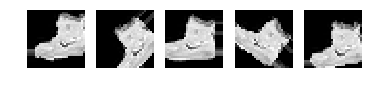

In [0]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

###  Report the final train and validation accuracy

## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

### **Load CIFAR10 dataset**

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

### **Prepare/fit the generator.**

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**